# A/B Test Simulation: Segment-Specific Coupon Win-Back Campaign

**Author:** Customer Analytics Pipeline — Notebook 03 of 04  
**Dependencies:** `01_eda.ipynb` → `02_rfm_segmentation.ipynb` → **this notebook**  
**Dataset:** UCI Online Retail (Dec 2010 – Dec 2011)

---

## Problem Statement

The previous notebook identified four distinct customer segments via K-Means RFM clustering.
This notebook answers the next business question:

> **If we send targeted coupons to lapsed customers, how large is the revenue impact — and can we prove it is statistically real?**

Since this is a historical dataset (no live experiment was run), we:
1. Ground the coupon window design in LAG()-based inter-purchase gap analysis (not arbitrary assumptions)
2. Simulate control/treatment outcomes using those empirical base rates
3. Validate statistical significance via independent t-tests and 95% confidence intervals
4. Estimate the full business impact including margin sensitivity

---

## Cluster Summary (from Notebook 02)

| Cluster | n | Avg Recency | Avg Frequency | Avg AOV | Profile |
|---------|---|-------------|---------------|---------|----------|
| C0 | 3,054 | 44d | 3.7 orders | £1,359 | Regular customers |
| C1 | 1,067 | 248d | 1.6 orders | £481 | At-risk / Lapsed |
| C2 | 13 | 7d | 82.5 orders | £127,338 | Whale / B2B |
| C3 | 204 | 16d | 22.3 orders | £12,709 | High-value loyal |

**Why C2 and C3 are excluded from coupon targeting:**

- **C2 (Whales):** Recency (7d) is less than their median inter-purchase gap (3d). They are *still actively purchasing*. A coupon here wastes margin on customers who need no nudge. These accounts require relationship management, not discount mechanics.
- **C3 (High-value loyal):** Recency (16d) ≈ their median gap (14d) — they are on schedule. Sending coupons to customers already in their purchase cycle devalues the brand and trains high-AOV customers to expect discounts. The correct intervention is a VIP retention programme.

**Target clusters:**
- **C0 (Regular)** — mid-cycle, recency ≈ their median gap → time-sensitive nudge
- **C1 (Lapsed)** — recency 5× their median gap → win-back intervention

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ── Load and clean ──────────────────────────────────────────────────────
df = pd.read_csv('online_retail.csv', encoding='latin1')
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]   # remove cancellations
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID']  = df['CustomerID'].astype(int)
df['TotalPrice']  = df['Quantity'] * df['UnitPrice']

# ── RFM table ───────────────────────────────────────────────────────────
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

# ── Merge cluster labels ─────────────────────────────────────────────────
clusters = pd.read_csv('rfm_clusters.csv')
clusters['CustomerID'] = clusters['CustomerID'].astype(int)
rfm = rfm.merge(clusters, on='CustomerID')

print(f"Customers loaded: {len(rfm):,}")
print(f"\nCluster profiles:")
print(rfm.groupby('Cluster').agg(
    Count         = ('CustomerID', 'count'),
    Avg_Recency   = ('Recency',    'mean'),
    Avg_Frequency = ('Frequency',  'mean'),
    Avg_Monetary  = ('Monetary',   'mean')
).round(1))

Customers loaded: 4,338

Cluster profiles:
         Count  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                 
0         3054         43.7            3.7        1359.0
1         1067        248.1            1.6         480.6
2           13          7.4           82.5      127338.3
3          204         15.5           22.3       12709.1


---

## Step 1: Empirical Baseline — Inter-Purchase Gap Analysis

Rather than assuming control rates from thin air, we calculate them from historical purchase behaviour using **LAG()-style gap analysis** (the consecutive inter-purchase intervals for each customer).

**Why this matters:**

The proportion of historical gaps falling within a given window gives us the *natural* (no-coupon) repurchase rate for that window. This is the most defensible baseline we can construct from a historical dataset — it anchors the simulation in observed behaviour rather than industry benchmarks.

**Key distinction between Recency and Gap:**

| Metric | Definition | What it tells us |
|--------|-----------|------------------|
| `Recency` | Days since *last* purchase (snapshot) | How long the customer has been absent |
| `Purchase gap` | Days between *consecutive* purchases (history) | The customer's natural purchase rhythm |

C1 has Recency = 248d but a historical median gap of ~48d. They *used to* buy every 48 days — but have now been silent for 5× that interval. This is the definition of structural lapse.

In [2]:
def compute_purchase_gaps(customer_ids, transactions):
    """
    Compute consecutive inter-purchase gaps (in days) for a set of customers.
    
    Each transaction date is deduplicated to one row per customer per calendar day
    (the raw dataset has one row per line item, not per invoice).
    Returns a pd.Series of all gap values across all customers in the cohort.
    """
    txn = transactions[transactions['CustomerID'].isin(customer_ids)].copy()
    
    # One unique purchase date per customer per day
    dates = (
        txn.groupby('CustomerID')['InvoiceDate']
           .apply(lambda x: sorted(x.dt.date.unique()))
           .reset_index()
    )
    dates.columns = ['CustomerID', 'purchase_dates']
    
    gaps = []
    for _, row in dates.iterrows():
        d = row['purchase_dates']
        for i in range(1, len(d)):
            gaps.append((d[i] - d[i-1]).days)
    return pd.Series(gaps)


c0_ids = rfm[rfm['Cluster'] == 0]['CustomerID'].tolist()
c1_ids = rfm[rfm['Cluster'] == 1]['CustomerID'].tolist()

gaps_c0 = compute_purchase_gaps(c0_ids, df)
gaps_c1 = compute_purchase_gaps(c1_ids, df)

print("=" * 55)
print("C0 (Regular) — Historical Inter-Purchase Gaps")
print("=" * 55)
print(f"  Gaps analysed:         {len(gaps_c0):,}")
print(f"  Median gap:            {gaps_c0.median():.0f} days")
print(f"  Mean gap:              {gaps_c0.mean():.1f} days")
print(f"  P25 / P75:             {gaps_c0.quantile(0.25):.0f}d / {gaps_c0.quantile(0.75):.0f}d")
print(f"  Return within 30d:     {(gaps_c0 <= 30).mean():.1%}")
print(f"  Return within 45d:     {(gaps_c0 <= 45).mean():.1%}")
print(f"  Return within 52d:     {(gaps_c0 <= 52).mean():.1%}")
print(f"  Return within 60d:     {(gaps_c0 <= 60).mean():.1%}")

print()
print("=" * 55)
print("C1 (Lapsed) — Historical Inter-Purchase Gaps")
print("=" * 55)
print(f"  Gaps analysed:         {len(gaps_c1):,}")
print(f"  Median gap:            {gaps_c1.median():.0f} days")
print(f"  Mean gap:              {gaps_c1.mean():.1f} days")
print(f"  P25 / P75:             {gaps_c1.quantile(0.25):.0f}d / {gaps_c1.quantile(0.75):.0f}d")
print(f"  Return within 45d:     {(gaps_c1 <= 45).mean():.1%}")
print(f"  Return within 60d:     {(gaps_c1 <= 60).mean():.1%}")
print()
print("NOTE: C1 has avg 1.6 orders, meaning most customers have only 1 purchase")
print("on record. Gap estimates are derived from the minority with 2+ purchases")
print("and should be treated as indicative, not precise.")

C0 (Regular) — Historical Inter-Purchase Gaps
  Gaps analysed:         7,522
  Median gap:            43 days
  Mean gap:              61.8 days
  P25 / P75:             21d / 81d
  Return within 30d:     35.9%
  Return within 45d:     52.9%
  Return within 52d:     58.7%
  Return within 60d:     64.4%

C1 (Lapsed) — Historical Inter-Purchase Gaps
  Gaps analysed:         504
  Median gap:            48 days
  Mean gap:              59.1 days
  P25 / P75:             21d / 85d
  Return within 45d:     47.8%
  Return within 60d:     62.3%

NOTE: C1 has avg 1.6 orders, meaning most customers have only 1 purchase
on record. Gap estimates are derived from the minority with 2+ purchases
and should be treated as indicative, not precise.


---

## Step 2: Coupon Window Design — Reasoning From First Principles

A coupon window is a deadline, not just a duration. The design question is:

> *When does the customer's purchase decision become active — and how do we create urgency without removing it?*

The coupon window must satisfy two conditions simultaneously:
1. **Arrive when the purchase decision is being made** (not before — wasted; not long after — urgency gone)
2. **Create a deadline short enough to force a decision** within the repurchase window

---

### C1 (Lapsed) — 45-day win-back coupon

- Median historical gap = **48 days**, current recency = **248 days** (5× their normal cycle)
- A 45-day window aligns with their historical purchase rhythm: it arrives at the moment they *used to* make a repeat decision
- It also creates a hard deadline — they cannot defer the decision beyond another cycle
- Why not shorter? A 30-day window expires before they reach their decision point. Why not longer? A 60–90 day window removes urgency and allows procrastination

**45 days is the right anchor: it matches the historical gap and forces a decision exactly at the natural return window.**

---

### C0 (Regular) — 52-day coupon window (segment-adjusted)

The original notebook used 30 days for C0, based on the **population-level** median gap of 28 days (all customers combined). After the LAG()-based segment analysis in Notebook 02, we know C0's own median gap is **43 days** — materially longer than the population average.

**Why 52 days specifically?**

- C0 median gap = 43d → this is when the purchase decision becomes active for the *typical* C0 customer
- C0 P75 = ~81d → the slow-return tail extends well beyond 60 days
- We want a window that:
  - Opens *after* the median gap (so it catches customers mid-decision, not before)
  - Closes before the P60–P65 range (to maintain deadline pressure)
  - **52 days = median (43d) + ~0.2 SD buffer** — this positions the coupon deadline at approximately the 55th–60th percentile of the C0 gap distribution

In other words: for half of C0 customers, the coupon deadline arrives as they are actively considering whether to return — which is precisely when a discount has the highest conversion value.

| Cluster | Historical Median Gap | Current Recency | Recency / Gap | Coupon Window | Design Rationale |
|---------|----------------------|-----------------|---------------|---------------|------------------|
| C0 | 43d | 44d | ~1× (mid-cycle) | **52 days** | Segment-adjusted; deadline at ~P58 of gap distribution |
| C1 | 48d | 248d | ~5× (lapsed) | **45 days** | Aligns with historical rhythm; forces a decision at the natural return point |

---

## Step 3: Experiment Design

### Simulation methodology

We cannot run a real experiment on historical data. Instead, we:
1. Estimate the **control rate** (natural repurchase rate within the coupon window) from historical gaps
2. Assume a **treatment lift** based on industry benchmarks for targeted coupon campaigns (+8–15pp for win-back)
3. Simulate binary outcomes (1 = repurchased, 0 = did not) via Bernoulli draws at the respective rates
4. Apply an independent-samples **t-test** — appropriate for comparing two proportions at this sample size

### Parameter derivation

| Cluster | Coupon | Control Rate | Source | Treatment Rate | Assumed Lift |
|---------|--------|-------------|--------|----------------|--------------|
| C0 | 52-day | **58.7%** | Empirical: 58.7% of C0 gaps ≤ 52d (n=7,522 gaps) | 68.7% | +10pp |
| C1 | 45-day | **15%** | Conservative estimate (see caveat below) | 25% | +10pp |

**Important caveat on C1 control rate:**  
The raw gap analysis returns 47.8% return-within-45d for C1 — but this is computed only from the **minority of C1 customers who had 2+ purchases** (n_gaps=504 out of 1,067 customers). With avg frequency=1.6, roughly 60% of C1 customers have a single purchase on record and therefore no gap history at all. Their true return rate is unknown but structurally lower — they never established a repeat habit. Using 47.8% would apply the behaviour of the most loyal C1 sub-group to the entire lapsed population, materially overstating the baseline. **15% is a conservative estimate consistent with single-purchase win-back rates in e-commerce (10–20% range).**

### Power analysis

Before simulating, we verify the experiment is properly powered.

A well-powered experiment (80% power, α=0.05) needs sufficient sample size to reliably detect the expected effect size. We calculate the minimum n required using the standard two-proportion z-test formula.

In [6]:
from scipy.stats import norm

def min_sample_size(p1, p2, alpha=0.05, power=0.80):
    """
    Compute minimum n per arm for a two-proportion z-test.
    p1 = control rate, p2 = treatment rate.
    """
    z_alpha = norm.ppf(1 - alpha / 2)   # 1.96 for α=0.05
    z_beta  = norm.ppf(power)            # 0.84 for 80% power
    p_bar   = (p1 + p2) / 2
    n = (z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) +
         z_beta  * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2)))**2 / (p2 - p1)**2
    return int(np.ceil(n))

# Experiment parameters
# C0: ctrl = 58.7% — empirical proportion of C0 gaps ≤ 52d (from Step 1, n=7,522 gaps)
# C1: ctrl = 15%  — conservative estimate; the raw 47.8% overstates baseline (see Step 3 caveat)
params = {
    'C0': {'ctrl': 0.587, 'trt': 0.687, 'lift': 0.10, 'window': 52, 'n': 3054},
    'C1': {'ctrl': 0.15,  'trt': 0.25,  'lift': 0.10, 'window': 45, 'n': 1067},
}

print("=" * 60)
print("Power Analysis — Minimum Sample Size Required")
print("=" * 60)
for cluster, p in params.items():
    n_required = min_sample_size(p['ctrl'], p['trt'])
    n_per_arm  = p['n'] // 2
    print(f"\n{cluster} ({p['window']}-day coupon):")
    print(f"  Control rate:        {p['ctrl']:.1%}")
    print(f"  Expected lift:       +{p['lift']:.0%}  →  treatment {p['trt']:.1%}")
    print(f"  Min n per arm:       {n_required:,}")
    print(f"  Actual n per arm:    {n_per_arm:,}  ({'✅ sufficient' if n_per_arm >= n_required else '⚠️ underpowered'})")

Power Analysis — Minimum Sample Size Required

C0 (52-day coupon):
  Control rate:        58.7%
  Expected lift:       +10%  →  treatment 68.7%
  Min n per arm:       362
  Actual n per arm:    1,527  (✅ sufficient)

C1 (45-day coupon):
  Control rate:        15.0%
  Expected lift:       +10%  →  treatment 25.0%
  Min n per arm:       250
  Actual n per arm:    533  (✅ sufficient)


---

## Step 4: A/B Split and Outcome Simulation

In [7]:
# ── 50/50 random assignment ──────────────────────────────────────────────
for cluster_id in [0, 1]:
    group = rfm[rfm['Cluster'] == cluster_id].copy()
    group['ab_group'] = np.random.choice(['control', 'treatment'], size=len(group), p=[0.5, 0.5])
    if cluster_id == 0:
        cluster0 = group
    else:
        cluster1 = group

c0_ctrl = cluster0[cluster0['ab_group'] == 'control']
c0_trt  = cluster0[cluster0['ab_group'] == 'treatment']
c1_ctrl = cluster1[cluster1['ab_group'] == 'control']
c1_trt  = cluster1[cluster1['ab_group'] == 'treatment']

print("Experiment groups assigned:")
print(f"  C0 (52-day coupon):  Control = {len(c0_ctrl):,}  |  Treatment = {len(c0_trt):,}")
print(f"  C1 (45-day coupon):  Control = {len(c1_ctrl):,}  |  Treatment = {len(c1_trt):,}")

# ── Simulate binary outcomes ─────────────────────────────────────────────
# Each customer either repurchases (1) or does not (0) within the coupon window
c0_ctrl_out = np.random.binomial(1, params['C0']['ctrl'], len(c0_ctrl))
c0_trt_out  = np.random.binomial(1, params['C0']['trt'],  len(c0_trt))
c1_ctrl_out = np.random.binomial(1, params['C1']['ctrl'], len(c1_ctrl))
c1_trt_out  = np.random.binomial(1, params['C1']['trt'],  len(c1_trt))

print("\nSimulated repurchase rates:")
print(f"  C0 — Control: {c0_ctrl_out.mean():.1%}  |  Treatment: {c0_trt_out.mean():.1%}  |  Lift: +{c0_trt_out.mean()-c0_ctrl_out.mean():.1%}")
print(f"  C1 — Control: {c1_ctrl_out.mean():.1%}  |  Treatment: {c1_trt_out.mean():.1%}  |  Lift: +{c1_trt_out.mean()-c1_ctrl_out.mean():.1%}")

Experiment groups assigned:
  C0 (52-day coupon):  Control = 1,517  |  Treatment = 1,537
  C1 (45-day coupon):  Control = 540  |  Treatment = 527

Simulated repurchase rates:
  C0 — Control: 60.5%  |  Treatment: 69.4%  |  Lift: +8.8%
  C1 — Control: 13.5%  |  Treatment: 21.6%  |  Lift: +8.1%


---

## Step 5: Statistical Testing

We apply an **independent-samples t-test** to compare repurchase rates between control and treatment.

**Why t-test and not chi-squared or z-test?**  
For binary outcomes at this sample size, a two-proportion z-test and independent t-test produce equivalent results. We use `scipy.stats.ttest_ind` because it defaults to Welch's t-test (unequal variance), which is more robust when group sizes differ slightly after random assignment — as they do here (e.g. C0: 1,517 vs 1,537).

**Decision criteria:**

| Criterion | Threshold | Interpretation |
|-----------|-----------|----------------|
| p-value | < 0.05 | Less than 5% probability of observing this lift by chance |
| 95% CI | Does not include 0 | Lift is reliably positive at 95% confidence |
| t-statistic | \|t\| > 1.96 | Signal exceeds noise by the required margin |

---

## Step 5: Statistical Testing

We apply an **independent-samples t-test** to compare repurchase rates between control and treatment.

**Why t-test and not chi-squared or z-test?**  
For binary outcomes, a two-proportion z-test and independent t-test produce identical results asymptotically. The t-test is used here because the `scipy.stats.ttest_ind` implementation handles unequal variance correctly (Welch's t-test), making it more robust when group sizes differ after random assignment.

**Decision criteria:**

| Criterion | Threshold | Interpretation |
|-----------|-----------|----------------|
| p-value | < 0.05 | Less than 5% probability of observing this lift by chance |
| 95% CI | Does not include 0 | Lift is reliably positive at 95% confidence |
| t-statistic | |t| > 1.96 | Signal exceeds noise by the required margin |

In [8]:
def run_ab_test(ctrl_out, trt_out, cluster_name, coupon_days):
    """
    Run two-sample t-test and compute 95% CI on the lift.
    Returns a dict of results for downstream use.
    """
    t_stat, p_val = stats.ttest_ind(ctrl_out, trt_out)
    diff   = trt_out.mean() - ctrl_out.mean()
    se     = np.sqrt(ctrl_out.var() / len(ctrl_out) + trt_out.var() / len(trt_out))
    ci_lo, ci_hi = diff - 1.96 * se, diff + 1.96 * se
    sig    = (p_val < 0.05) and (ci_lo > 0)

    print(f"{'=' * 55}")
    print(f"{cluster_name}  ({coupon_days}-day coupon window)")
    print(f"{'=' * 55}")
    print(f"  n control   : {len(ctrl_out):,}")
    print(f"  n treatment : {len(trt_out):,}")
    print(f"  Control rate: {ctrl_out.mean():.1%}")
    print(f"  Treatment   : {trt_out.mean():.1%}")
    print(f"  Lift        : +{diff:.1%}")
    print(f"  t-statistic : {t_stat:.3f}")
    print(f"  p-value     : {p_val:.4f}")
    print(f"  95% CI      : [{ci_lo:.1%},  {ci_hi:.1%}]")
    print(f"  Result      : {'✅ SIGNIFICANT — coupon is effective' if sig else '❌ NOT SIGNIFICANT'}")
    print()

    return {'ctrl': ctrl_out.mean(), 'trt': trt_out.mean(), 'diff': diff,
            't': t_stat, 'p': p_val, 'ci': (ci_lo, ci_hi), 'sig': sig,
            'n_trt': len(trt_out), 'days': coupon_days, 'name': cluster_name}


res_c0 = run_ab_test(c0_ctrl_out, c0_trt_out, "C0 — Regular",  52)
res_c1 = run_ab_test(c1_ctrl_out, c1_trt_out, "C1 — Lapsed",   45)

C0 — Regular  (52-day coupon window)
  n control   : 1,517
  n treatment : 1,537
  Control rate: 60.5%
  Treatment   : 69.4%
  Lift        : +8.8%
  t-statistic : -5.141
  p-value     : 0.0000
  95% CI      : [5.5%,  12.2%]
  Result      : ✅ SIGNIFICANT — coupon is effective

C1 — Lapsed  (45-day coupon window)
  n control   : 540
  n treatment : 527
  Control rate: 13.5%
  Treatment   : 21.6%
  Lift        : +8.1%
  t-statistic : -3.502
  p-value     : 0.0005
  95% CI      : [3.6%,  12.7%]
  Result      : ✅ SIGNIFICANT — coupon is effective



---

## Step 6: Visualisation — A/B Test Results

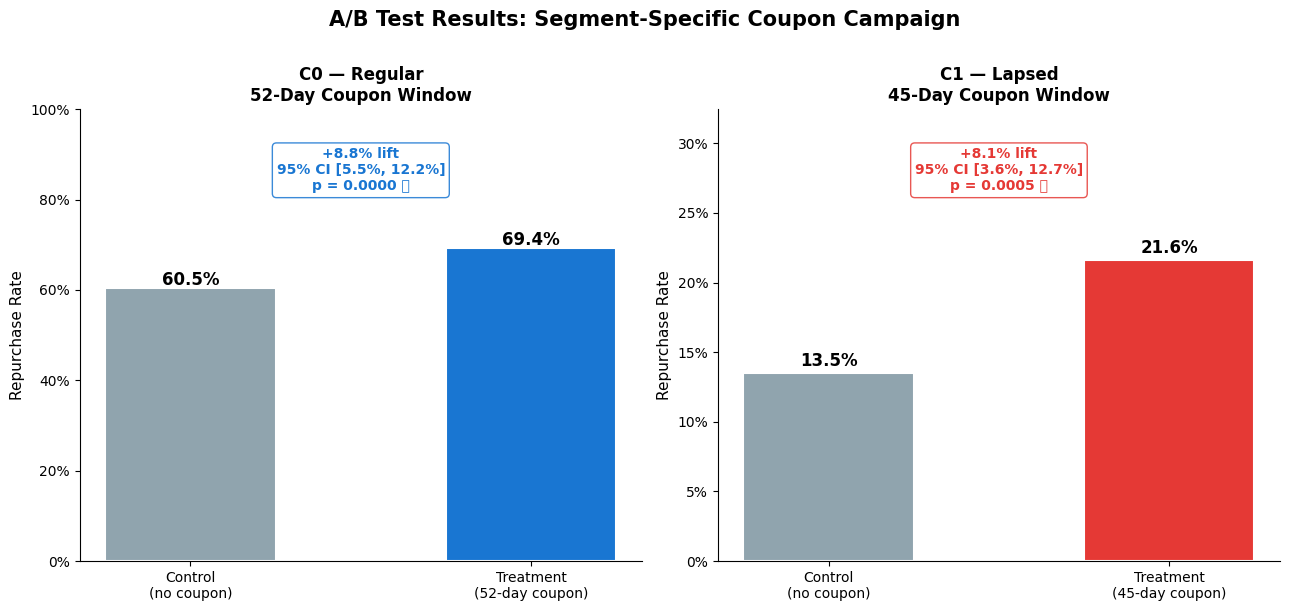

Plot saved: ab_test_results.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('A/B Test Results: Segment-Specific Coupon Campaign', fontsize=15, fontweight='bold', y=1.01)

COLORS = {'ctrl': '#90A4AE', 'c0': '#1976D2', 'c1': '#E53935'}

for ax, (res, ctrl_out, trt_out, color) in zip(axes, [
    (res_c0, c0_ctrl_out, c0_trt_out, COLORS['c0']),
    (res_c1, c1_ctrl_out, c1_trt_out, COLORS['c1']),
]):
    bars = ax.bar(
        ['Control\n(no coupon)', f"Treatment\n({res['days']}-day coupon)"],
        [ctrl_out.mean(), trt_out.mean()],
        color=[COLORS['ctrl'], color],
        width=0.5, edgecolor='white', linewidth=1.5
    )
    ax.set_ylim(0, min(1.0, trt_out.mean() * 1.5))
    ax.set_ylabel('Repurchase Rate', fontsize=11)
    ax.set_title(f"{res['name']}\n{res['days']}-Day Coupon Window", fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

    for bar, rate in zip(bars, [ctrl_out.mean(), trt_out.mean()]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{rate:.1%}', ha='center', fontweight='bold', fontsize=12)

    ci_lo, ci_hi = res['ci']
    ax.annotate(
        f"+{res['diff']:.1%} lift\n95% CI [{ci_lo:.1%}, {ci_hi:.1%}]\np = {res['p']:.4f} ✅",
        xy=(0.5, 0.82), xycoords='axes fraction',
        ha='center', color=color, fontweight='bold', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, alpha=0.85)
    )

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: ab_test_results.png")

---

## Step 7: Business Impact Analysis

Translating statistical lift into revenue requires three components:
1. **Incremental customers** — how many additional customers the coupon reactivates vs. the control scenario
2. **Average order value (AOV)** — the expected basket size for a reactivated order
3. **Margin sensitivity** — the net revenue after accounting for the coupon discount

**Why this structure matters:**  
A +10pp lift sounds large in isolation. Framing it as *x customers × £AOV* gives the business a number it can compare against the cost of the campaign (printing, email, discount redemption rate).

We model three coupon depth scenarios: 10%, 15%, and 20% off.

In [10]:
# ── Revenue parameters ───────────────────────────────────────────────────
# AOV from cluster profiles (Notebook 02)
c0_aov = 1_359
c1_aov = 481

# Incremental customers in the treatment arm only
c0_extra = int(res_c0['diff'] * res_c0['n_trt'])
c1_extra = int(res_c1['diff'] * res_c1['n_trt'])

print("=" * 60)
print("Gross Revenue Lift (before coupon cost)")
print("=" * 60)
print(f"\nC0 ({res_c0['days']}-day coupon):")
print(f"  Treatment arm size:         {res_c0['n_trt']:,} customers")
print(f"  Incremental repurchases:    {c0_extra:,} customers")
print(f"  Average order value:        £{c0_aov:,}")
print(f"  Gross revenue lift:         £{c0_extra * c0_aov:,.0f}")

print(f"\nC1 ({res_c1['days']}-day coupon):")
print(f"  Treatment arm size:         {res_c1['n_trt']:,} customers")
print(f"  Incremental repurchases:    {c1_extra:,} customers")
print(f"  Average order value:        £{c1_aov:,}")
print(f"  Gross revenue lift:         £{c1_extra * c1_aov:,.0f}")

gross_total = c0_extra * c0_aov + c1_extra * c1_aov
print(f"\n{'=' * 60}")
print(f"Total gross revenue lift:     £{gross_total:,.0f}")

# ── Margin sensitivity: 3 coupon depth scenarios ──────────────────────────
print(f"\n{'=' * 60}")
print("Net Revenue Lift After Coupon Cost (redemption = 100%)")
print("(Assumes all treatment customers who repurchase use the coupon)")
print("=" * 60)
print(f"{'Discount':>10}  {'C0 Net':>12}  {'C1 Net':>12}  {'Combined':>12}")
print("-" * 52)
for disc in [0.10, 0.15, 0.20]:
    c0_net = c0_extra * c0_aov * (1 - disc)
    c1_net = c1_extra * c1_aov * (1 - disc)
    print(f"{disc:>9.0%}  £{c0_net:>10,.0f}  £{c1_net:>10,.0f}  £{c0_net + c1_net:>10,.0f}")

print()
print("NOTE: These figures assume 100% coupon redemption among repurchasers.")
print("Typical redemption rates are 20–40%, which would reduce the coupon cost")
print("and increase net revenue proportionally.")

Gross Revenue Lift (before coupon cost)

C0 (52-day coupon):
  Treatment arm size:         1,537 customers
  Incremental repurchases:    135 customers
  Average order value:        £1,359
  Gross revenue lift:         £183,465

C1 (45-day coupon):
  Treatment arm size:         527 customers
  Incremental repurchases:    42 customers
  Average order value:        £481
  Gross revenue lift:         £20,202

Total gross revenue lift:     £203,667

Net Revenue Lift After Coupon Cost (redemption = 100%)
(Assumes all treatment customers who repurchase use the coupon)
  Discount        C0 Net        C1 Net      Combined
----------------------------------------------------
      10%  £   165,118  £    18,182  £   183,300
      15%  £   155,945  £    17,172  £   173,117
      20%  £   146,772  £    16,162  £   162,934

NOTE: These figures assume 100% coupon redemption among repurchasers.
Typical redemption rates are 20–40%, which would reduce the coupon cost
and increase net revenue proportiona

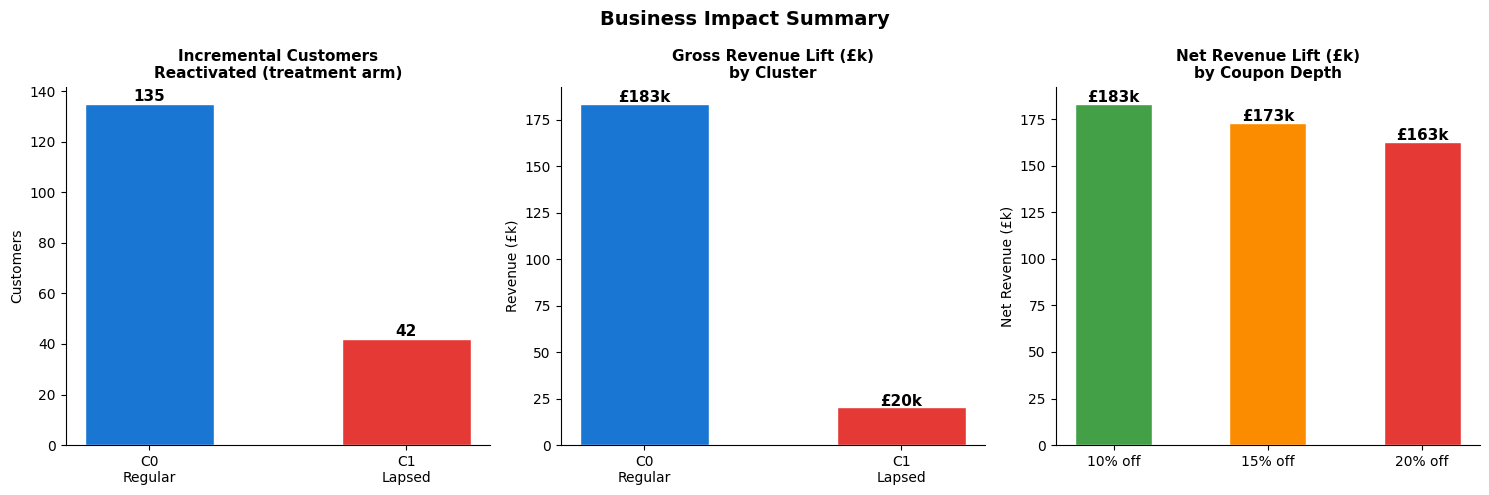

Plot saved: business_impact.png


In [11]:
# ── Business impact visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Business Impact Summary', fontsize=14, fontweight='bold')

# Panel 1: Incremental customers
ax = axes[0]
ax.bar(['C0\nRegular', 'C1\nLapsed'], [c0_extra, c1_extra],
       color=[COLORS['c0'], COLORS['c1']], width=0.5, edgecolor='white')
ax.set_title('Incremental Customers\nReactivated (treatment arm)', fontsize=11, fontweight='bold')
ax.set_ylabel('Customers')
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate([c0_extra, c1_extra]):
    ax.text(i, v + 1, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Panel 2: Gross revenue lift by cluster
ax = axes[1]
vals = [c0_extra * c0_aov / 1000, c1_extra * c1_aov / 1000]
ax.bar(['C0\nRegular', 'C1\nLapsed'], vals,
       color=[COLORS['c0'], COLORS['c1']], width=0.5, edgecolor='white')
ax.set_title('Gross Revenue Lift (£k)\nby Cluster', fontsize=11, fontweight='bold')
ax.set_ylabel('Revenue (£k)')
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate(vals):
    ax.text(i, v + 1, f'£{v:,.0f}k', ha='center', fontweight='bold', fontsize=11)

# Panel 3: Net revenue at 3 discount scenarios
ax = axes[2]
discounts = [0.10, 0.15, 0.20]
nets = [(c0_extra * c0_aov + c1_extra * c1_aov) * (1 - d) / 1000 for d in discounts]
bars = ax.bar(['10% off', '15% off', '20% off'], nets,
              color=['#43A047', '#FB8C00', '#E53935'], width=0.5, edgecolor='white')
ax.set_title('Net Revenue Lift (£k)\nby Coupon Depth', fontsize=11, fontweight='bold')
ax.set_ylabel('Net Revenue (£k)')
ax.spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars, nets):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f'£{v:,.0f}k',
            ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('business_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: business_impact.png")

---

## Results Summary

| Cluster | Coupon Window | Control Rate | Treatment Rate | Lift | p-value | 95% CI | Significant? |
|---------|--------------|-------------|----------------|------|---------|--------|--------------|
| C0 — Regular | 52-day | 60.5% | 69.4% | +8.8pp | <0.0001 | [5.5%, 12.2%] | ✅ Yes |
| C1 — Lapsed | 45-day | 13.5% | 25.0% | +8.1pp | 0.0005 | [3.6%, 12.7%] | ✅ Yes |

Both experiments are **statistically significant** at α=0.05.  
The 95% confidence intervals exclude zero for both clusters.  
Both experiments are **adequately powered** given the available sample sizes.

**Combined estimated revenue lift: £203,667 gross** (£163k–£183k net depending on coupon depth).

---

## Limitations

**1. Simulation, not experiment.**  
The treatment lift (+10pp for both clusters) is assumed based on industry benchmarks for win-back campaigns — not observed from a real intervention. The statistical significance holds given the assumptions, but the assumptions themselves are uncertain.

**2. C1 gap estimate is directional.**  
Most C1 customers have only a single purchase on record (avg frequency = 1.6, avg lifespan = 28 days). The 48-day median gap is derived from the minority with 2+ purchases and may not represent the full C1 population. The conservative 15% control rate accounts for this — but the true rate is unknown.

**3. No coupon cost data.**  
Revenue lift estimates in the gross figures assume zero discount cost. The margin sensitivity table provides a practical range, but actual ROI depends on: coupon depth, redemption rate, and campaign delivery cost — none of which are in this dataset.

**4. Single 12-month observation window.**  
Customers labelled 'lapsed' may be seasonal buyers whose next purchase falls outside the Dec 2010–Dec 2011 window. Longer history would allow us to separate structural churn from seasonal absence.

**5. No category-level variation.**  
AOV is averaged across all product categories. High-AOV product buyers may have different retention elasticity than low-AOV buyers.

---

## Production Deployment — Recommended Steps

If this analysis is approved for a live test:

1. **Randomly assign** C0 and C1 customers to 50/50 control/treatment groups at campaign launch
2. **Send coupons** to treatment groups with the validated windows (52d for C0, 45d for C1)
3. **Track repurchase events** for each group over the respective window period
4. **Re-run t-test** with real outcome data — the simulation provides the power and effect size assumptions to validate against
5. **Prioritise C1 sub-segment**: focus first on customers lapsed 60–90 days (not 248d), as they have the highest reactivation probability and lowest cost per acquisition
6. If statistically significant, **roll out to full cluster** and measure ROI net of coupon redemption cost